# Relatorio de teste com logs Sysmon
Execute as celulas em ordem para gerar metricas, SHAP/LIME e o relatorio final.

In [1]:
import os
import sys
import subprocess
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import ipaddress
import joblib
import matplotlib.pyplot as plt

def ensure_package(import_name, pip_name=None):
    try:
        __import__(import_name)
        return
    except Exception:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

ensure_package("Evtx", "python-evtx")
ensure_package("shap")
ensure_package("lime")

from Evtx.Evtx import Evtx
import xml.etree.ElementTree as ET
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path("..").resolve()
MODEL_PATH = ROOT / "Train" / "modelo_ransomware.joblib"
DATASET_PATH = ROOT / "Datasets" / "LMD-2023-dataset.csv"
LOGS_DIR = ROOT / "RansomwaresLogs"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
assert LOGS_DIR.exists(), f"Logs dir not found: {LOGS_DIR}"

rf = joblib.load(MODEL_PATH)
rf

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [4]:
import joblib
import sys
sys.path.append('..')
from parser.feature_engineering import extract_behavioral_features

df_train_raw = pd.read_csv(DATASET_PATH, low_memory=False)
df_train_raw = df_train_raw[df_train_raw['Label'] != 2].copy()

print('Extracting baseline behavioral features...')
df_train_behavioral = extract_behavioral_features(df_train_raw)
drop_cols = [
    'Label',
    'ProcessId',
    'ProcessGuid',
    'ProcessKey',
    '_log_file',
    'Image'
]
X_train = df_train_behavioral.drop(columns=drop_cols, errors='ignore')

scaler = joblib.load(ROOT / 'Train' / 'preprocessor.joblib')
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)


2026-05-26 23:45:14,856 - INFO - Starting feature engineering


Extracting baseline behavioral features...


2026-05-26 23:45:58,591 - INFO - Extracted features for 13014 unique processes


In [5]:
import sys
sys.path.append('..')
from parser.evtx_parser import parse_all_evtx

print('Parsing all EVTX files...')
df_logs_raw = parse_all_evtx(LOGS_DIR)
print('events:', len(df_logs_raw), 'columns:', len(df_logs_raw.columns))

df_logs = extract_behavioral_features(df_logs_raw)
df_logs.head()


2026-05-26 23:46:14,377 - INFO - Found 4 EVTX files in C:\Projetos\RansonwareData\RansomwaresLogs
2026-05-26 23:46:14,377 - INFO - Parsing cerber.evtx...


Parsing all EVTX files...


2026-05-26 23:46:16,664 - INFO - Parsing locky.evtx...
2026-05-26 23:46:17,228 - INFO - Parsing teslacrypt.evtx...
2026-05-26 23:46:17,599 - INFO - Parsing wannacry.evtx...
2026-05-26 23:46:18,350 - INFO - Parsed 751 total events.
2026-05-26 23:46:18,353 - INFO - Starting feature engineering


events: 751 columns: 47


2026-05-26 23:46:18,647 - INFO - Extracted features for 102 unique processes


,ProcessKey,Image,total_events,events_per_second,max_events_same_second,num_created_processes,num_created_files,file_creation_rate,num_registry_modifications,num_network_connections,num_dns_queries,num_unique_ips,num_unique_ports,suspicious_extensions,unique_extensions_modified,critical_directory_activity,child_process_count,suspicious_command_count,Label
0,{0ce852ef-4b0b-6a16-a601-000000001100},c:\users\paulo\appdata\local\microsoft\onedriv...,1,1.0,1,0,0,0.0,0,0,0,0,0,0,1,0,1,0,-1
1,{0ce852ef-4b0b-6a16-a801-000000001100},c:\users\paulo\appdata\local\microsoft\onedriv...,1,1.0,1,0,0,0.0,0,0,1,0,0,0,1,0,1,0,-1
2,{0ce852ef-4c29-6a16-fa01-000000001100},c:\windows\system32\wevtutil.exe,1,1.0,1,1,0,0.0,0,0,0,0,0,0,1,0,1,1,-1
3,{0ce852ef-4c37-6a16-fb01-000000001100},c:\windows\system32\sihclient.exe,1,1.0,1,1,0,0.0,0,0,0,0,0,0,1,0,1,0,-1
4,{0ce852ef-4c37-6a16-fc01-000000001100},c:\windows\servicing\trustedinstaller.exe,1,1.0,1,1,0,0.0,0,0,0,0,0,0,1,0,1,0,-1


In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

X_logs = df_logs.drop(columns=['Label', 'ProcessId', '_log_file'], errors='ignore')
# Align missing columns with train features
for col in X_train.columns:
    if col not in X_logs.columns:
        X_logs[col] = 0
X_logs = X_logs[X_train.columns]
X_logs_scaled = pd.DataFrame(scaler.transform(X_logs), columns=X_logs.columns)

pred_original = rf.predict(X_logs_scaled)
classes = list(getattr(rf, 'classes_', [0, 1]))
pos_label = 1 if 1 in classes else classes[-1]

if hasattr(rf, 'predict_proba'):
    prob = rf.predict_proba(X_logs_scaled)
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    prob_pos = prob[:, pos_index]
else:
    prob_pos = np.full(len(pred_original), np.nan)

threshold = 0.15
pred = np.where(prob_pos > threshold, pos_label, 0)

df_logs['pred_label'] = pred
df_logs['prob_ransomware'] = prob_pos

# Print summary
summary = df_logs.groupby('ProcessKey').agg(
    total_events=('total_events', 'mean'),
    predicted_ransomware_rate=('pred_label', lambda x: float(np.mean(x == pos_label))),
    avg_prob_ransomware=('prob_ransomware', 'mean'),
    max_prob_ransomware=('prob_ransomware', 'max')
).reset_index()

print('Predicao por Processo (Ransomware se Prob > 0.15):')
summary['log_pred_label'] = np.where(summary['avg_prob_ransomware'] > threshold, pos_label, 0)
print(summary)


Predicao por Processo (Ransomware se Prob > 0.15):
                                 ProcessKey  total_events  \
0    {0ce852ef-4b0b-6a16-a601-000000001100}           1.0   
1    {0ce852ef-4b0b-6a16-a801-000000001100}           1.0   
2    {0ce852ef-4c29-6a16-fa01-000000001100}           1.0   
3    {0ce852ef-4c37-6a16-fb01-000000001100}           1.0   
4    {0ce852ef-4c37-6a16-fc01-000000001100}           1.0   
..                                      ...           ...   
97   {0ce852ef-aa67-6a13-db01-000000001100}           1.0   
98   {0ce852ef-aa67-6a13-dc01-000000001100}           1.0   
99   {0ce852ef-aa67-6a13-dd01-000000001100}           1.0   
100  {0ce852ef-aa6d-6a13-de01-000000001100}           1.0   
101  {0ce852ef-aa6e-6a13-df01-000000001100}           1.0   

     predicted_ransomware_rate  avg_prob_ransomware  max_prob_ransomware  \
0                          0.0             0.000000             0.000000   
1                          0.0             0.091189             

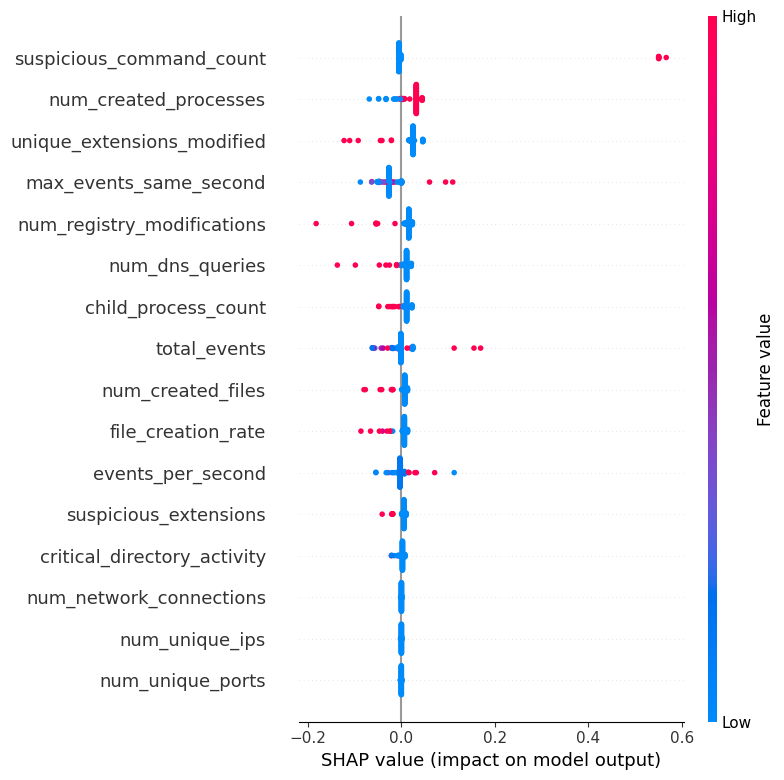

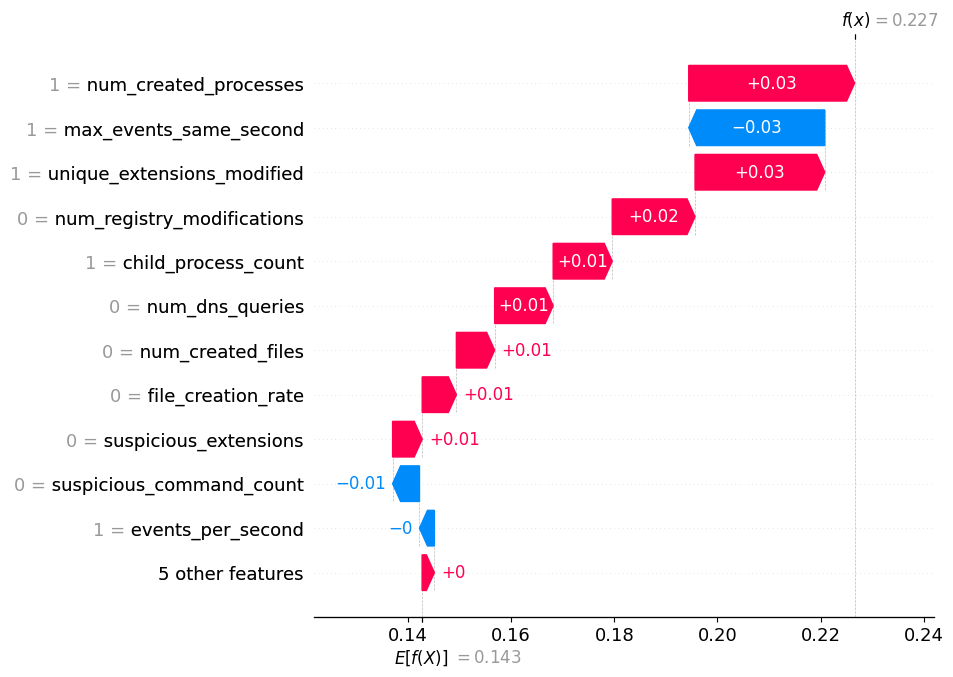

In [8]:
sample_logs = X_logs.sample(n=min(200, len(X_logs)), random_state=42)
train_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)

explainer = shap.TreeExplainer(rf, data=train_sample)
sv_all = explainer.shap_values(sample_logs)

if isinstance(sv_all, list):
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[pos_index]
elif isinstance(sv_all, np.ndarray) and sv_all.ndim == 3:
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[:, :, pos_index]
else:
    sv = sv_all

shap.summary_plot(sv, sample_logs, show=True)
plt.show()

instance_idx = 0
sv_row = sv[instance_idx] if hasattr(sv, "__getitem__") else np.array(sv)[instance_idx]
row = sample_logs.iloc[instance_idx]
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()
    base_value = float(base_value[pos_index]) if len(base_value) > pos_index else float(base_value[0])
else:
    base_value = float(base_value)

try:
    exp = shap.Explanation(
        values=sv_row,
        base_values=base_value,
        data=row.values,
        feature_names=sample_logs.columns.tolist(),
    )
    shap.plots.waterfall(exp, max_display=12)
    plt.show()
except Exception as e:
    print("waterfall failed:", e)

[('suspicious_command_count <= 0.00', -0.3512776567773694), ('total_events <= 1.00', -0.12194982894826868), ('num_dns_queries <= 0.00', 0.09226046403823053), ('0.00 < max_events_same_second <= 1.00', -0.08778973130942122), ('file_creation_rate <= 0.00', 0.07765363536798009), ('unique_extensions_modified <= 1.00', 0.07746491062078187), ('num_created_files <= 0.00', 0.07420236241762837), ('num_registry_modifications <= 0.00', 0.0725383436779036), ('suspicious_extensions <= 0.00', 0.05612053983133516), ('child_process_count <= 1.00', 0.04629720436883222)]


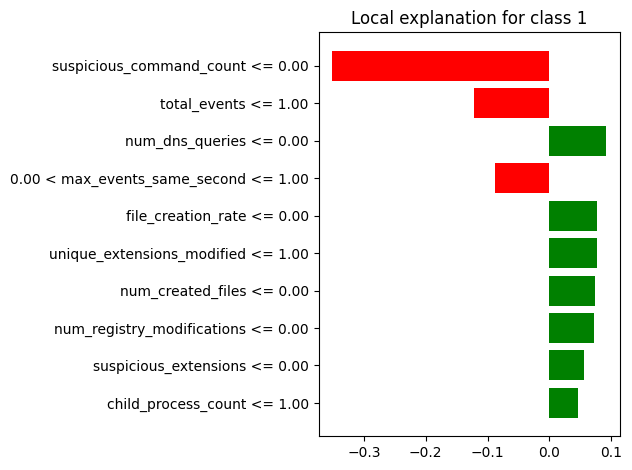

,feature,contribution
0,suspicious_command_count <= 0.00,-0.351278
1,total_events <= 1.00,-0.121950
2,num_dns_queries <= 0.00,0.092260
3,0.00 < max_events_same_second <= 1.00,-0.087790
4,file_creation_rate <= 0.00,0.077654
5,unique_extensions_modified <= 1.00,0.077465
6,num_created_files <= 0.00,0.074202
7,num_registry_modifications <= 0.00,0.072538
8,suspicious_extensions <= 0.00,0.056121
9,child_process_count <= 1.00,0.046297


In [9]:

# Garantir float
X_train = X_train.astype(float)
X_logs = X_logs.astype(float)

# Remover NaN e inf
X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_logs = X_logs.replace([np.inf, -np.inf], 0).fillna(0)

instance_idx = 0
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(c) for c in classes],
    mode="classification",
)

exp = lime_explainer.explain_instance(
    X_logs.iloc[instance_idx].values,
    rf.predict_proba,
    num_features=10,
)

print(exp.as_list())
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

df_lime = pd.DataFrame(exp.as_list(), columns=["feature", "contribution"])
df_lime

In [11]:
# Dataset com campo predict
predict_path = REPORT_DIR / "logs_dataset_with_predict.csv"

dataset_with_predict = dataset_for_predict.copy()
if "pred_label" in df_logs.columns:
    dataset_with_predict["predict"] = df_logs["pred_label"].values
else:
    dataset_with_predict["predict"] = pd.Series([None] * len(dataset_with_predict))
    print("pred_label column not found in df_logs")

dataset_with_predict.to_csv(predict_path, index=False)
print("Dataset with predict saved:", predict_path)


Dataset with predict saved: C:\Projetos\RansonwareData\Tests\Reports\logs_dataset_with_predict.csv


In [12]:
# Count total events and group by EventID
print("Total events:", len(df_logs))

if "EventID" in df_logs.columns:
    event_counts = df_logs["EventID"].value_counts().sort_index()
    display(event_counts)
else:
    print("EventID column not found in df_logs")

Total events: 102
EventID column not found in df_logs


In [13]:
# Dataset com resultados dos logs + groupby EventID
results_path = REPORT_DIR / "logs_results_dataset.csv"

cols = [c for c in ["_log_file", "EventID", "pred_label", "prob_ransomware"] if c in df_logs.columns]
df_results = df_logs[cols].copy()
df_results.to_csv(results_path, index=False)
print("Results dataset saved:", results_path)

if "EventID" in df_results.columns:
    event_counts_results = df_results["EventID"].value_counts().sort_index()
    display(event_counts_results)
else:
    print("EventID column not found in df_results")

Results dataset saved: C:\Projetos\RansonwareData\Tests\Reports\logs_results_dataset.csv
EventID column not found in df_results


In [14]:
# Checagem de linhas com pred_label=1 (ransomware)
if "pred_label" in df_logs.columns:
    ransomware_count = int((df_logs["pred_label"] == 1).sum())
    total_count = int(len(df_logs))
    print(f"ransomware_count: {ransomware_count} / {total_count}")
    if ransomware_count == 0:
        print("Nenhuma linha com pred_label=1 no df_logs.")
else:
    print("pred_label column not found in df_logs")


ransomware_count: 80 / 102
